# Análise de dados do PPGEEC no ano de 2021


In [ ]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

EXCEL_PATH = "2021_coleta.xlsx"
QUALIS_PATH = "qualis_capes.xlsx"
OUTPUT_DIR = Path("saida_indicadores_ppgeec")
OUTPUT_DIR.mkdir(exist_ok=True)

PRODUCAO_SHEET_CANDIDATES = [
    "Produções Intelectuais", "Producoes Intelectuais", "Produção Intelectual", "Producoes", "Produção"
]

MISSING_TOKENS = {"", "-", "--", "---", "na", "n/a", "null", "none", "nan", "não informado", "nao informado", "sem informacao", "sem informação", "ignorado"}
BOOLEAN_TRUE = {"sim", "s", "true", "1", "yes"}
BOOLEAN_FALSE = {"nao", "não", "n", "false", "0", "no"}

# **1. Mecanismos de limpeza aplicados para a base**

## 1.1 Mecanismos gerais para os dados
- padronização textual;
- tratamento de placeholders de ausência;
- detecção de sujeira;
- inferência de tipos.

## 1.2 **Estratégia para a aba de Produções Intelectuais**:  
Dados que precisam ser preservados
- autores;
- ordem dos autores;
- detalhamentos como ISSN, DOI, idioma e periódico.

In [ ]:
def normalize_text(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    text_ascii = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    if text_ascii.lower().strip() in MISSING_TOKENS:
        return np.nan
    return text

def snake_case(text):
    if text is None:
        return text
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("utf-8")
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def is_probably_date(series, threshold=0.7):
    if series.dropna().empty:
        return False
    return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold

def is_probably_numeric(series, threshold=0.8):
    if series.dropna().empty:
        return False
    coerced = pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")
    return coerced.notna().mean() >= threshold

def is_probably_boolean(series, threshold=0.9):
    if series.dropna().empty:
        return False
    vals = (series.dropna().astype(str).str.strip().str.lower()
            .map(lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")))
    return vals.isin(BOOLEAN_TRUE.union(BOOLEAN_FALSE)).mean() >= threshold

def standardize_dataframe(df):
    out = df.copy().dropna(axis=1, how="all")
    for col in out.columns:
        if out[col].dtype == "object":
            out[col] = out[col].map(normalize_text)
    return out

def describe_column_type(series):
    s = series.copy()
    if pd.api.types.is_datetime64_any_dtype(s):
        logical = "datetime"
    elif pd.api.types.is_numeric_dtype(s):
        logical = "numerico"
    elif is_probably_date(s):
        logical = "data_textual"
    elif is_probably_numeric(s):
        logical = "numerico_textual"
    elif is_probably_boolean(s):
        logical = "booleano_textual"
    else:
        nunique = s.nunique(dropna=True)
        total = max(len(s.dropna()), 1)
        logical = "categorica_textual" if (nunique / total) < 0.5 else "texto_livre"

    return {
        "dtype_pandas": str(s.dtype),
        "tipo_logico": logical,
        "n_total": int(len(s)),
        "n_na": int(s.isna().sum()),
        "pct_na": round(float(s.isna().mean() * 100), 2) if len(s) else 0.0,
        "n_unicos": int(s.nunique(dropna=True)),
    }

def detect_dirty_patterns(df):
    rows = []
    for col in df.columns:
        s = df[col]
        total = len(s)
        if s.dtype == "object":
            raw = s.astype(str)
            spaces_edge = int((raw != raw.str.strip()).sum())
            multi_spaces = int(raw.str.contains(r"\s{2,}", regex=True, na=False).sum())
            empty_like = int(
                s.fillna("").astype(str).str.strip().str.lower()
                 .map(lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8"))
                 .isin(MISSING_TOKENS).sum()
            )
        else:
            spaces_edge = 0
            multi_spaces = 0
            empty_like = 0

        invalid_dates = 0
        if is_probably_date(s):
            parsed = pd.to_datetime(s, errors="coerce", dayfirst=True)
            invalid_dates = max(0, int(parsed.isna().sum() - s.isna().sum()))

        n_nulos = int(s.isna().sum())
        pct_nulos = round(float(n_nulos / total * 100), 2) if total else 0.0
        n_unicos = int(s.nunique(dropna=True))
        coluna_constante = int(n_unicos <= 1)

        score = pct_nulos * 2 + empty_like * 1.5 + invalid_dates * 1.5 + spaces_edge + multi_spaces + coluna_constante * 10

        rows.append({
            "coluna": col,
            "nulos": n_nulos,
            "pct_nulos": pct_nulos,
            "espacos_inicio_fim": spaces_edge,
            "multiplos_espacos": multi_spaces,
            "placeholders_ausencia": empty_like,
            "datas_invalidas": invalid_dates,
            "valores_unicos": n_unicos,
            "coluna_constante": coluna_constante,
            "score_sujeira": round(score, 2),
        })
    return pd.DataFrame(rows).sort_values("score_sujeira", ascending=False).reset_index(drop=True)

| Nome da Função | Descrição Resumida |
| :--- | :--- |
| `normalize_text` | Limpa strings, remove acentos, espaços extras e converte tokens vazios em `NaN`. |
| `snake_case` | Converte textos para o padrão `minusculo_com_underscore`, removendo caracteres especiais. |
| `is_probably_date` | Verifica se uma coluna textual possui dados que podem ser interpretados como data. |
| `is_probably_numeric` | Avalia se uma coluna de texto contém predominantemente valores numéricos. |
| `is_probably_boolean` | Identifica se a coluna contém valores que representam estados lógicos (Verdadeiro/Falso). |
| `standardize_dataframe` | Aplica a normalização de texto em todas as colunas de strings de um DataFrame. |
| `describe_column_type` | Gera metadados e identifica o tipo lógico da coluna (ex: categórica vs texto livre). |
| `detect_dirty_patterns` | Analisa a "saúde" dos dados, identificando espaços, nulos e gerando um score de sujeira. |

## 2. Leitura da base principal e da planilha Qualis

A planilha Qualis contém, no mínimo:
- ISSN
- título da revista/periódico
- Qualis

In [ ]:
def load_excel_sheets(excel_path):
    xls = pd.ExcelFile(excel_path)
    return {sheet_name: pd.read_excel(excel_path, sheet_name=sheet_name) for sheet_name in xls.sheet_names}

def load_qualis_table(path):
    path = Path(path)
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except Exception:
            return pd.read_csv(path, sep=";", encoding="utf-8-sig")
    raise ValueError("Use .xlsx, .xls ou .csv para a planilha Qualis.")

def find_production_sheet_name(sheet_names, candidates):
    normalized = {snake_case(s): s for s in sheet_names}
    for cand in candidates:
        if snake_case(cand) in normalized:
            return normalized[snake_case(cand)]
    for s in sheet_names:
        s_norm = snake_case(s)
        if "produc" in s_norm and ("intelect" in s_norm or s_norm == "producoes"):
            return s
    raise ValueError("Não foi possível localizar automaticamente a aba de Produções Intelectuais.")

sheets_raw = load_excel_sheets(EXCEL_PATH)
sheets_std = {name: standardize_dataframe(df) for name, df in sheets_raw.items()}
qualis_raw = load_qualis_table(QUALIS_PATH)
qualis_std = standardize_dataframe(qualis_raw)

production_sheet_name = find_production_sheet_name(list(sheets_std.keys()), PRODUCAO_SHEET_CANDIDATES)

print("Aba de produção intelectual:", production_sheet_name)
print("Abas encontradas:", list(sheets_std.keys()))
print("Shape da base Qualis:", qualis_std.shape)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

Aba de produção intelectual: Produção Intelectual
Abas encontradas: ['Programa', 'Proposta', 'Financiadores', 'Linhas de Pesquisa', 'Projetos de Pesquisa', 'Disciplinas', 'Turmas', 'Docentes', 'Discentes', 'Participantes Externos', 'Trabalhos de Conclusão', 'Produção Intelectual', 'Produções Mais Relevantes', 'Pós-Doc', 'Projeto de Cooperação entre Ins', 'Egresso']
Shape da base Qualis: (3053, 3)


## 3. Diagnóstico Inicial da Aba de Produções Intelectuais

Analisando a natureza dos dados da aba.

Objetivos desta etapa

- Entender a **granularidade dos dados**
- Identificar **problemas estruturais**
- Avaliar **qualidade dos campos críticos (ISSN, autores, etc.)**
- Verificar se a base está adequada para cálculo de indicadores

---

### Estrutura observada

A base de Produções Intelectuais apresenta uma estrutura **normalizada (long format)**, onde:

- Uma única produção aparece em múltiplas linhas
- As linhas representam:
  - diferentes **detalhamentos** (ISSN, DOI, idioma, etc.)
  - diferentes **autores**

Isso implica que:

- A tabela não está pronta para análise direta
- É necessário reconstruir entidades como:
  - Produção
  - Autoria
  - Detalhamento

---

### Problemas potenciais identificados

- Redundância de registros por produção
- ISSN embutido em texto não estruturado
- Produções sem autores explícitos
- Possível perda de informação após agrupamentos anteriores

---

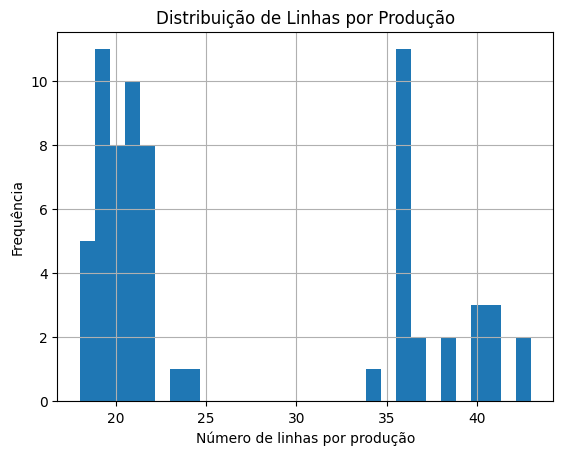

In [ ]:
df_prod = sheets_std[production_sheet_name].copy()

df_prod['id_producao'] = (
    df_prod['Título da Produção'].str.strip().str.upper() + "_" +
    df_prod['Ano da Produção'].astype(str)
)

linhas_por_producao = df_prod.groupby('id_producao').size()

import matplotlib.pyplot as plt

plt.figure()
linhas_por_producao.hist(bins=30)
plt.title("Distribuição de Linhas por Produção")
plt.xlabel("Número de linhas por produção")
plt.ylabel("Frequência")
plt.show()


## Observa-se que cada produção possui múltiplas linhas associadas.

Formato normalizado da base!

- cada linha representa um atributo ou autor
- e não uma produção única

---

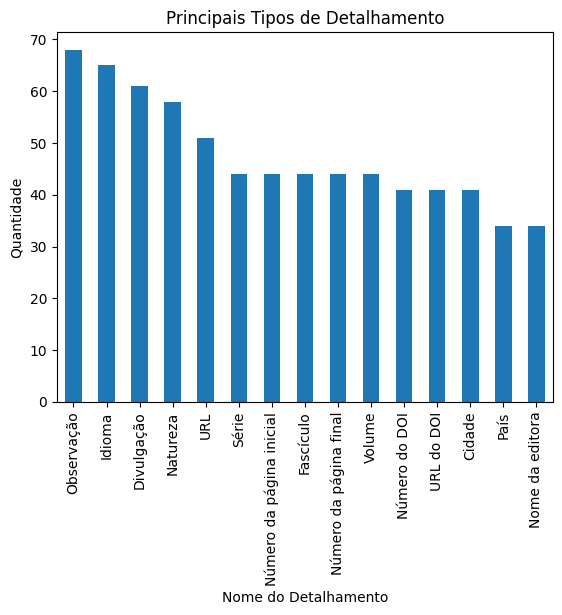

In [ ]:
detalhamento_counts = (
    df_prod['Nome do Detalhamento']
    .value_counts()
    .head(15)
)

plt.figure()
detalhamento_counts.plot.bar()
plt.title("Principais Tipos de Detalhamento")
plt.ylabel("Quantidade")
plt.show()

## Os detalhamentos representam metadados da produção, como:

- ISSN
- DOI
- idioma
- editora

!! Não descartar ISSN, DOI...

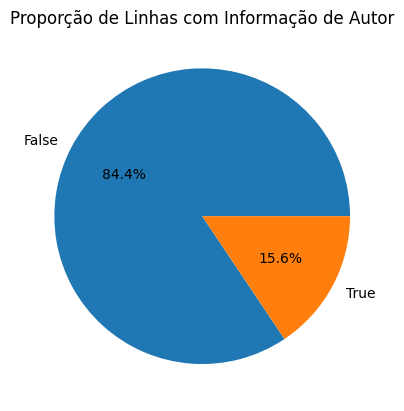

In [ ]:
tem_autor = df_prod['Nome do Autor'].notna()

counts = tem_autor.value_counts()

plt.figure()
counts.plot.pie(autopct='%1.1f%%')
plt.title("Proporção de Linhas com Informação de Autor")
plt.ylabel("")
plt.show()


## Observa-se que nem todas as linhas possuem informação de autoria.

Isso ocorre porque:

- algumas linhas representam apenas detalhamentos da produção

Portanto, é necessário separar:

- dados de autoria
- dados de metadados


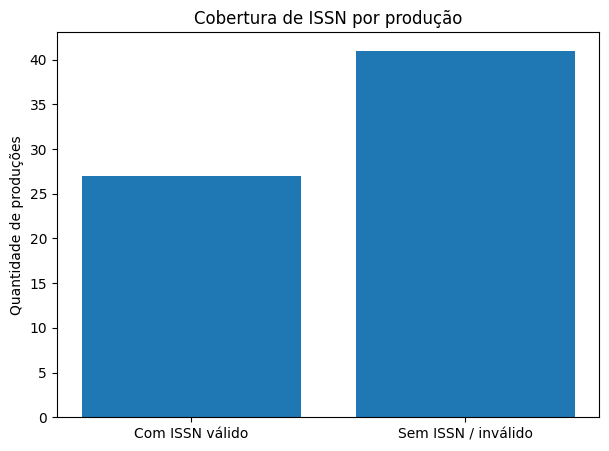

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def extrair_issn(valor):
    if pd.isna(valor):
        return None
    match = re.search(r'\d{4}-\d{3}[\dXx]', str(valor))
    return match.group(0) if match else None

df_prod["id_producao"] = (
    df_prod["Título da Produção"].astype(str).str.strip().str.upper()
    + "_"
    + df_prod["Ano da Produção"].astype(str).str.strip()
)

df_issn_linhas = df_prod[
    df_prod["Nome do Detalhamento"].astype(str).str.strip() == "ISSN / Título do periódico"
].copy()

df_issn_linhas["ISSN"] = df_issn_linhas["Valor do Detalhamento"].apply(extrair_issn)

issn_por_producao = (
    df_issn_linhas.groupby("id_producao")["ISSN"]
    .apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else None)
    .reset_index()
)

todas_producoes = df_prod[["id_producao"]].drop_duplicates()
cobertura_issn = todas_producoes.merge(issn_por_producao, on="id_producao", how="left")
issn_validos = cobertura_issn["ISSN"].notna().sum()
issn_invalidos_ou_ausentes = cobertura_issn["ISSN"].isna().sum()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Com ISSN válido", "Sem ISSN / inválido"],
    [issn_validos, issn_invalidos_ou_ausentes]
)
plt.title("Cobertura de ISSN por produção")
plt.ylabel("Quantidade de produções")
plt.show()

In [ ]:
import re
import pandas as pd
import numpy as np
df_prod = df_prod.copy()

df_prod["id_producao"] = (
    df_prod["Título da Produção"].astype(str).str.strip().str.upper()
    + "_"
    + df_prod["Ano da Produção"].astype(str).str.strip()
)


def extrair_issn(valor):
    if pd.isna(valor):
        return None
    match = re.search(r"\b\d{4}-\d{3}[\dXx]\b", str(valor))
    return match.group(0).upper() if match else None

def extrair_isbn(valor):
    if pd.isna(valor):
        return None
    texto = str(valor).upper().replace("ISBN", "").strip()
    match = re.search(r"\b(?:97[89][-\s]?)?\d(?:[-\s]?\d){8,16}\b", texto)
    if match:
        return re.sub(r"[\s-]+", "", match.group(0))
    return None

def extrair_doi(valor):
    if pd.isna(valor):
        return None
    texto = str(valor).strip()
    match = re.search(r"(10\.\d{4,9}/[-._;()/:A-Z0-9]+)", texto, flags=re.I)
    return match.group(1).upper() if match else None

def safe_upper(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()

df_prod["tipo_norm"] = df_prod["Tipo da Produção"].apply(safe_upper)
df_prod["subtipo_norm"] = df_prod["Subtipo da Produção"].apply(safe_upper)
df_prod["detalhamento_norm"] = df_prod["Nome do Detalhamento"].apply(safe_upper)


def classificar_estrato(tipo, subtipo):
    texto = f"{tipo} | {subtipo}"

    if "ARTIGO EM PERIÓDICO" in texto:
        return "ARTIGO_PERIODICO"

    if "LIVRO" in texto and "CAPÍTULO" not in texto and "CAPITULO" not in texto:
        return "LIVRO"

    if "CAPÍTULO" in texto or "CAPITULO" in texto:
        return "CAPITULO_LIVRO"

    if "ANAIS" in texto or "EVENTO" in texto or "TRABALHO EM EVENTO" in texto:
        return "TRABALHO_EVENTO"

    if "PATENTE" in texto:
        return "PATENTE"

    return "OUTROS"


classificacao_producao = (
    df_prod.groupby("id_producao")[["tipo_norm", "subtipo_norm"]]
    .agg(lambda s: s.dropna().iloc[0] if not s.dropna().empty else "")
    .reset_index()
)

classificacao_producao["estrato_producao"] = classificacao_producao.apply(
    lambda row: classificar_estrato(row["tipo_norm"], row["subtipo_norm"]),
    axis=1
)


df_meta = df_prod.copy()


df_meta["issn_extraido"] = np.where(
    df_meta["detalhamento_norm"].str.contains("ISSN", na=False),
    df_meta["Valor do Detalhamento"].apply(extrair_issn),
    None
)

df_meta["isbn_extraido"] = np.where(
    df_meta["detalhamento_norm"].str.contains("ISBN", na=False),
    df_meta["Valor do Detalhamento"].apply(extrair_isbn),
    None
)

df_meta["doi_extraido"] = np.where(
    df_meta["detalhamento_norm"].str.contains("DOI", na=False),
    df_meta["Valor do Detalhamento"].apply(extrair_doi),
    None
)

def primeiro_valido(serie):
    serie = serie.dropna()
    serie = serie[serie.astype(str).str.strip() != ""]
    return serie.iloc[0] if not serie.empty else None

identificadores_por_producao = (
    df_meta.groupby("id_producao")[["issn_extraido", "isbn_extraido", "doi_extraido"]]
    .agg(primeiro_valido)
    .reset_index()
)


df_estratificado = classificacao_producao.merge(
    identificadores_por_producao,
    on="id_producao",
    how="left"
)


def identificador_esperado(estrato):
    mapa = {
        "ARTIGO_PERIODICO": "ISSN",
        "LIVRO": "ISBN",
        "CAPITULO_LIVRO": "ISBN",
        "TRABALHO_EVENTO": "DOI/ISBN/ISSN",
        "PATENTE": "SEM_IDENT_BIBLIO",
        "OUTROS": "NAO_DEFINIDO"
    }
    return mapa.get(estrato, "NAO_DEFINIDO")

df_estratificado["identificador_esperado"] = df_estratificado["estrato_producao"].apply(identificador_esperado)


def possui_identificador_esperado(row):
    estrato = row["estrato_producao"]

    if estrato == "ARTIGO_PERIODICO":
        return pd.notna(row["issn_extraido"])

    if estrato in ["LIVRO", "CAPITULO_LIVRO"]:
        return pd.notna(row["isbn_extraido"])

    if estrato == "TRABALHO_EVENTO":
        return (
            pd.notna(row["doi_extraido"]) or
            pd.notna(row["isbn_extraido"]) or
            pd.notna(row["issn_extraido"])
        )

    if estrato == "PATENTE":
        return True

    return None  # não avaliado

df_estratificado["possui_identificador_esperado"] = df_estratificado.apply(
    possui_identificador_esperado,
    axis=1
)


resumo_estratos = (
    df_estratificado.groupby("estrato_producao")
    .agg(
        total_producoes=("id_producao", "nunique"),
        com_issn=("issn_extraido", lambda s: s.notna().sum()),
        com_isbn=("isbn_extraido", lambda s: s.notna().sum()),
        com_doi=("doi_extraido", lambda s: s.notna().sum()),
        com_identificador_esperado=("possui_identificador_esperado", lambda s: (s == True).sum()),
        sem_identificador_esperado=("possui_identificador_esperado", lambda s: (s == False).sum())
    )
    .reset_index()
)

resumo_estratos["pct_com_identificador_esperado"] = (
    resumo_estratos["com_identificador_esperado"] / resumo_estratos["total_producoes"] * 100
).round(2)

display(df_estratificado.head(10))
display(resumo_estratos)

,id_producao,tipo_norm,subtipo_norm,estrato_producao,issn_extraido,isbn_extraido,doi_extraido,identificador_esperado,possui_identificador_esperado
0,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,ARTIGO_PERIODICO,2169-3536,None,10.1109/ACCESS.2021.3074360,ISSN,True
1,A SEMI-DISTRIBUTED APPROACH FOR UPLINK MAX-MIN...,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,ARTIGO_PERIODICO,1980-6604,None,10.14209/JCIS.2021.9,ISSN,True
2,AERIAL RECONFIGURABLE INTELLIGENT SURFACE-AIDE...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
3,ANALYSIS OF ASYMMETRIC DUAL-HOP ENERGY HARVEST...,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,ARTIGO_PERIODICO,2473-2400,None,None,ISSN,True
4,ANÁLISE COMPARATIVA DA INFLUÊNCIA DE OTIMIZADO...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
5,ANÁLISE DE REDES NEURAIS CONVOLUCIONAIS E TÉCN...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
6,ANÁLISE DE TOPOLOGIAS EM TRAÇADOR DE CURVA I-V...,BIBLIOGRÁFICA,LIVRO,LIVRO,None,9786589145837,None,ISBN,True
7,ANÁLISE DO CURSO DE ENGENHARIA ELÉTRICA DO CAM...,BIBLIOGRÁFICA,LIVRO,LIVRO,None,9786589145837,None,ISBN,True
8,BACKSCATTER COOPERATION IN NOMA COMMUNICATIONS...,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,ARTIGO_PERIODICO,1536-1276,None,None,ISSN,True
9,BEHAVIOR ANALYSIS OF PV MODULES SUBJECTED TO H...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False


,estrato_producao,total_producoes,com_issn,com_isbn,com_doi,com_identificador_esperado,sem_identificador_esperado,pct_com_identificador_esperado
0,ARTIGO_PERIODICO,27,27,0,12,27,0,100.0
1,LIVRO,7,0,7,0,7,0,100.0
2,OUTROS,1,0,0,0,0,0,0.0
3,PATENTE,3,0,0,0,3,0,100.0
4,TRABALHO_EVENTO,30,0,0,0,0,30,0.0


<Figure size 1000x600 with 0 Axes>

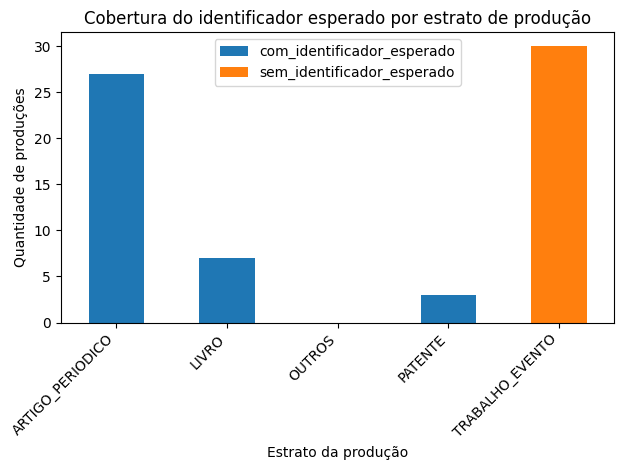

In [ ]:
import matplotlib.pyplot as plt

graf = resumo_estratos.set_index("estrato_producao")[
    ["com_identificador_esperado", "sem_identificador_esperado"]
]

plt.figure(figsize=(10, 6))
graf.plot(kind="bar", stacked=True)
plt.title("Cobertura do identificador esperado por estrato de produção")
plt.xlabel("Estrato da produção")
plt.ylabel("Quantidade de produções")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Nem todos os registros possuem ISSN válido extraível.

Isso impacta diretamente:

- a associação com a base Qualis
- o cálculo dos indicadores DPI e PR


In [ ]:
producao_raw = sheets_std[production_sheet_name].copy()
dirty_producao = detect_dirty_patterns(producao_raw)

display(producao_raw.head(10))
display(dirty_producao.head(10))

/tmp/ipykernel_30869/1805873757.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold
/tmp/ipykernel_30869/1805873757.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold
/tmp/ipykernel_30869/1805873757.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold
/tmp/ipykernel_30869/1805873757.py:23: UserWarning: Cou

,Calendário,Ano do Calendário,Data-Hora do Envio,Código do PPG,Nome do PPG,Área de Avaliação,IES Sigla,IES Nome,Ano da Produção,Título da Produção,Produção Glosada?,Tipo da Produção,Subtipo da Produção,Área de Concentração,Linha de Pesquisa,Projeto de Pesquisa,Nome do Detalhamento,Valor do Detalhamento,Nome do Autor,Categoria do Autor,Número de Ordem Autor
0,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Cidade,NaN,NaN,NaN,NaN
1,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Divulgação,MEIO DIGITAL,NaN,NaN,NaN
2,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Fascículo,NaN,NaN,NaN,NaN
3,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Idioma,INGLES,NaN,NaN,NaN
4,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,ISSN / Título do periódico,2169-3536 / (2169-3536) IEEE ACCESS,NaN,NaN,NaN
5,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Natureza,Completo,NaN,NaN,NaN
6,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Nome da editora,NaN,NaN,NaN,NaN
7,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Número da página final,NaN,NaN,NaN,NaN
8,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Número da página inicial,NaN,NaN,NaN,NaN
9,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM 

,coluna,nulos,pct_nulos,espacos_inicio_fim,multiplos_espacos,placeholders_ausencia,datas_invalidas,valores_unicos,coluna_constante,score_sujeira
0,Nome do Autor,1520,84.40,0,0,1520,0,169,0,2448.80
1,Categoria do Autor,1520,84.40,0,0,1520,0,5,0,2448.80
2,Valor do Detalhamento,1065,59.13,0,0,1065,0,275,0,1715.76
3,Nome do Detalhamento,281,15.60,0,0,281,0,93,0,452.70
4,Projeto de Pesquisa,183,10.16,0,0,183,0,13,0,294.82
5,Número de Ordem Autor,1520,84.40,0,0,0,0,8,0,168.80
6,Linha de Pesquisa,34,1.89,0,0,34,0,3,0,54.78
7,Área de Concentração,34,1.89,0,0,34,0,2,0,54.78
8,Nome do PPG,0,0.00,0,0,0,0,1,1,10.00
9,Calendário,0,0.00,0,0,0,0,1,1,10.00


## 4. Nova modelagem para este objetivo

Agora separamos a aba em três entidades analíticas:

### *producoes_base*
Uma linha por produção.

### *detalhamentos_base*
Uma linha por detalhamento associado à produção.

### *autorias_base*
Uma linha por autor associado à produção.

Essa etapa é o coração do novo problema.

In [ ]:
PRODUCAO_CORE_COLS = [
    "Calendário", "Ano do Calendário", "Data-Hora do Envio", "Código do PPG", "Nome do PPG",
    "Área de Avaliação", "IES Sigla", "IES Nome", "Ano da Produção", "Título da Produção",
    "Produção Glosada?", "Tipo da Produção", "Subtipo da Produção", "Área de Concentração",
    "Linha de Pesquisa", "Projeto de Pesquisa"
]
DETAIL_COL_NAME = "Nome do Detalhamento"
DETAIL_VAL_COL = "Valor do Detalhamento"
AUTHOR_NAME_COL = "Nome do Autor"
AUTHOR_CAT_COL = "Categoria do Autor"
AUTHOR_ORDER_COL = "Número de Ordem Autor"

def assert_columns_exist(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Colunas ausentes: {missing}")

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def unique_join(series, sep=" | "):
    vals = pd.Series(series).dropna().astype(str).str.strip()
    vals = vals[vals != ""]
    vals = pd.unique(vals)
    return sep.join(vals) if len(vals) else np.nan

def build_production_id(df):
    req = ["Código do PPG", "Ano da Produção", "Título da Produção", "Tipo da Produção", "Subtipo da Produção"]
    assert_columns_exist(df, req)
    out = df.copy()
    out["id_producao"] = (
        out["Código do PPG"].astype(str).str.strip() + "||" +
        out["Ano da Produção"].astype(str).str.strip() + "||" +
        out["Título da Produção"].astype(str).str.upper().str.strip() + "||" +
        out["Tipo da Produção"].astype(str).str.upper().str.strip() + "||" +
        out["Subtipo da Produção"].astype(str).str.upper().str.strip()
    )
    return out

def extract_issn(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"\b\d{4}-\d{3}[\dXx]\b", str(value))
    return match.group(0).upper() if match else np.nan

def normalize_issn(value):
    if pd.isna(value):
        return np.nan
    text = str(value).upper().strip()
    match = re.search(r"\b\d{4}-\d{3}[\dX]\b", text)
    return match.group(0) if match else np.nan

def split_production_entities(df):
    df = build_production_id(df)
    core_cols = [c for c in PRODUCAO_CORE_COLS if c in df.columns]

    producoes_base = (
        df[["id_producao"] + core_cols]
          .groupby("id_producao", as_index=False)
          .agg({c: first_non_null for c in core_cols})
    )

    assert_columns_exist(df, [DETAIL_COL_NAME, DETAIL_VAL_COL, AUTHOR_NAME_COL, AUTHOR_CAT_COL, AUTHOR_ORDER_COL])

    detalhamentos_base = (
        df[["id_producao", DETAIL_COL_NAME, DETAIL_VAL_COL]]
        .dropna(subset=[DETAIL_COL_NAME, DETAIL_VAL_COL], how="all")
        .copy()
    )

    autorias_base = (
        df[["id_producao", AUTHOR_NAME_COL, AUTHOR_CAT_COL, AUTHOR_ORDER_COL]]
        .dropna(subset=[AUTHOR_NAME_COL], how="all")
        .copy()
    )
    return producoes_base, detalhamentos_base, autorias_base

def pivot_detalhamentos(detalhamentos_base):
    work = detalhamentos_base.copy()
    work[DETAIL_COL_NAME] = work[DETAIL_COL_NAME].astype(str).str.strip()
    detalhe_pivot = (
        work.groupby(["id_producao", DETAIL_COL_NAME], as_index=False)[DETAIL_VAL_COL]
            .agg(unique_join)
            .pivot(index="id_producao", columns=DETAIL_COL_NAME, values=DETAIL_VAL_COL)
            .reset_index()
    )
    detalhe_pivot.columns.name = None
    if "ISSN / Título do periódico" in detalhe_pivot.columns:
        detalhe_pivot["ISSN_extraido"] = detalhe_pivot["ISSN / Título do periódico"].apply(extract_issn)
    else:
        detalhe_pivot["ISSN_extraido"] = np.nan
    return detalhe_pivot

def classify_docente(series_categoria):
    return series_categoria.astype(str).str.lower().str.contains("docente", na=False)

def prepare_authorship_base(autorias_base):
    out = autorias_base.copy()
    out[AUTHOR_NAME_COL] = out[AUTHOR_NAME_COL].map(normalize_text)
    out[AUTHOR_CAT_COL] = out[AUTHOR_CAT_COL].map(normalize_text)
    out[AUTHOR_ORDER_COL] = pd.to_numeric(out[AUTHOR_ORDER_COL], errors="coerce").astype("Int64")
    out["is_docente"] = classify_docente(out[AUTHOR_CAT_COL].fillna(""))
    return out

producoes_base, detalhamentos_base, autorias_base = split_production_entities(producao_raw)
detalhe_pivot = pivot_detalhamentos(detalhamentos_base)
autorias_prepared = prepare_authorship_base(autorias_base)

import ipywidgets as widgets
from IPython.display import display


out1 = widgets.Output(); out2 = widgets.Output(); out3 = widgets.Output()

with out1: display(producoes_base.head())
with out2: display(detalhamentos_base.head())
with out3: display(autorias_prepared.head())


tabs = widgets.Tab(children=[out1, out2, out3])
tabs.set_title(0, 'Produções')
tabs.set_title(1, 'Detalhamentos')
tabs.set_title(2, 'Autorias')

display(tabs)

## 5. Evidência do problema de granularidade

Aqui mostramos por que o agrupamento precisa ter cuidado: uma mesma produção pode ter:
- vários autores;
- vários detalhamentos;
- e a relação entre os dois não pode ser perdida.

In [ ]:
autores_por_prod = (
    autorias_prepared.groupby("id_producao", as_index=False)
    .agg(n_autores=(AUTHOR_NAME_COL, "count"),
         n_docentes_autores=("is_docente", "sum"))
)

detalhes_por_prod = (
    detalhamentos_base.groupby("id_producao", as_index=False)
    .agg(n_detalhamentos=(DETAIL_COL_NAME, "count"),
         n_tipos_detalhe=(DETAIL_COL_NAME, "nunique"))
)

granularidade_diag = (
    producoes_base[["id_producao", "Título da Produção", "Ano da Produção"]]
    .merge(autores_por_prod, on="id_producao", how="left")
    .merge(detalhes_por_prod, on="id_producao", how="left")
)

display(granularidade_diag.sort_values(["n_autores", "n_tipos_detalhe"], ascending=False).head(5))

,id_producao,Título da Produção,Ano da Produção,n_autores,n_docentes_autores,n_detalhamentos,n_tipos_detalhe
41,"22001018081P2||2021||METHODS, RADIO NETWORK NO...","METHODS, RADIO NETWORK NODE AND NETWORK NODE F...",2021,8,1,32,32
32,22001018081P2||2021||IRS-ASSISTED MASSIVE MIMO...,IRS-ASSISTED MASSIVE MIMO-NOMA NETWORKS WITH P...,2021,8,2,16,16
61,22001018081P2||2021||TENSOR-BASED LEARNING FRA...,TENSOR-BASED LEARNING FRAMEWORK FOR AUTOMATIC ...,2021,8,1,15,15
3,22001018081P2||2021||ANALYSIS OF ASYMMETRIC DU...,ANALYSIS OF ASYMMETRIC DUAL-HOP ENERGY HARVEST...,2021,7,1,15,15
13,22001018081P2||2021||CELL-FREE MASSIVE MIMO-NO...,CELL-FREE MASSIVE MIMO-NOMA SYSTEMS WITH IMPER...,2021,7,1,15,15


## 6. Preparação da planilha Qualis e correlação com a produção

O merge principal é feito via ISSN.  
Isso exige uma limpeza específica: extrair o ISSN do campo textual do detalhamento.

In [ ]:
def prepare_qualis_table(qualis_df):
    df = qualis_df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    col_map = {}
    for c in df.columns:
        c_norm = snake_case(c)
        if "issn" in c_norm and "titulo" not in c_norm:
            col_map["ISSN"] = c
        elif ("titulo" in c_norm or "revista" in c_norm or "periodico" in c_norm):
            col_map["TITULO_REVISTA"] = c
        elif "qualis" in c_norm:
            col_map["QUALIS"] = c

    if "ISSN" not in col_map:
        col_map["ISSN"] = df.columns[0]
    if "TITULO_REVISTA" not in col_map:
        col_map["TITULO_REVISTA"] = df.columns[1]
    if "QUALIS" not in col_map:
        col_map["QUALIS"] = df.columns[2]

    out = df[[col_map["ISSN"], col_map["TITULO_REVISTA"], col_map["QUALIS"]]].copy()
    out.columns = ["ISSN", "TITULO_REVISTA", "QUALIS"]

    out["ISSN"] = out["ISSN"].apply(normalize_issn)
    out["TITULO_REVISTA"] = out["TITULO_REVISTA"].map(normalize_text)
    out["QUALIS"] = out["QUALIS"].astype(str).str.upper().str.strip()

    validos = {"A1", "A2", "A3", "A4", "B1", "B2", "B3", "B4"}
    out["QUALIS_VALIDO"] = out["QUALIS"].where(out["QUALIS"].isin(validos), np.nan)

    out = out.dropna(subset=["ISSN"]).drop_duplicates(subset=["ISSN"], keep="first").reset_index(drop=True)
    return out

def enrich_productions_with_qualis(producoes_base, detalhe_pivot, qualis_prepared):
    out = producoes_base.merge(detalhe_pivot, on="id_producao", how="left")
    out["ISSN"] = out["ISSN_extraido"].apply(normalize_issn)
    out = out.merge(
        qualis_prepared[["ISSN", "TITULO_REVISTA", "QUALIS_VALIDO"]],
        on="ISSN",
        how="left"
    )
    out = out.rename(columns={"TITULO_REVISTA": "TITULO_REVISTA_QUALIS", "QUALIS_VALIDO": "QUALIS"})
    out["tem_issn"] = out["ISSN"].notna()
    out["tem_qualis"] = out["QUALIS"].notna()
    return out

qualis_prepared = prepare_qualis_table(qualis_std)
producoes_enriquecidas = enrich_productions_with_qualis(producoes_base, detalhe_pivot, qualis_prepared)

out1 = widgets.Output(); out2 = widgets.Output();

with out1: display(qualis_prepared.head())
with out2: display(producoes_enriquecidas[["id_producao", "Título da Produção", "ISSN", "QUALIS", "ISSN / Título do periódico"]].head(10))



tabs = widgets.Tab(children=[out1, out2])
tabs.set_title(0, 'Qualis')
tabs.set_title(1, 'Detalhamento')
display(tabs)


## 7. Regras do cálculo dos indicadores

### Pesos Qualis
- A1 = 1.00
- A2 = 0.875
- A3 = 0.75
- A4 = 0.60
- B1 = 0.30
- B2 = 0.20
- B3 = 0.10
- B4 = 0.05

### DPI
Para cada docente:
- soma-se a pontuação ponderada das produções em que ele aparece;
- depois a pontuação pode ser normalizada pelo `DP`, o número de docentes do programa.

$$DPI = \frac{A_1 + 0,875A_2 + 0,75A_3 + 0,6A_4 + 0,3B_1 + 0,2B_2 + 0,1B_3 + 0,05B_4}{DP}$$

### PR
Para cada produção:
- calcula-se a pontuação da produção;
- divide-se essa pontuação pelo número de **docentes autores do PPGEEC** naquela produção;
- cada docente recebe sua fração;
- ao final, soma-se por docente.

$$PR = A_1 + 0,875A_2 + 0,75A_3 + 0,6A_4 + 0,3B_1 + 0,2B_2 + 0,1B_3 + 0,05B_4$$

### Observação metodológica
O regulamento menciona fator `0,8` para publicação não aderente às Engenharias IV.  
Este notebook deixa essa parte configurável, porque a planilha Qualis de 3 colunas normalmente não carrega sozinha a informação objetiva de aderência.

In [ ]:
QUALIS_WEIGHTS = {
    "A1": 1.00, "A2": 0.875, "A3": 0.75, "A4": 0.60,
    "B1": 0.30, "B2": 0.20, "B3": 0.10, "B4": 0.05
}

def qualis_score(qualis):
    if pd.isna(qualis):
        return 0.0
    return float(QUALIS_WEIGHTS.get(str(qualis).upper().strip(), 0.0))

def add_indicator_inputs(producoes_enriquecidas_df, autorias_prepared_df, dp_docentes=None):
    prod = producoes_enriquecidas_df.copy()
    aut = autorias_prepared_df.copy()

    prod["pontuacao_qualis"] = prod["QUALIS"].apply(qualis_score)
    prod["fator_aderencia"] = 1.0
    prod["pontuacao_pr_base"] = prod["pontuacao_qualis"] * prod["fator_aderencia"]

    docentes_por_prod = (
        aut[aut["is_docente"]]
        .groupby("id_producao", as_index=False)
        .agg(n_docentes_autores=(AUTHOR_NAME_COL, "nunique"))
    )

    prod = prod.merge(docentes_por_prod, on="id_producao", how="left")
    prod["n_docentes_autores"] = prod["n_docentes_autores"].fillna(0).astype(int)

    docentes_distintos = aut.loc[aut["is_docente"], AUTHOR_NAME_COL].dropna().nunique()
    dp = dp_docentes if dp_docentes is not None else docentes_distintos
    return prod, aut, int(dp)

DP_DOCENTES_OFICIAL = None

producoes_indicadores, autorias_indicadores, DP = add_indicator_inputs(
    producoes_enriquecidas, autorias_prepared, dp_docentes=DP_DOCENTES_OFICIAL
)

autorias_com_prod = autorias_indicadores.merge(
    producoes_indicadores[
        ["id_producao", "Título da Produção", "Ano da Produção", "Tipo da Produção",
         "Subtipo da Produção", "QUALIS", "pontuacao_qualis", "pontuacao_pr_base", "n_docentes_autores"]
    ],
    on="id_producao",
    how="left"
)

autorias_docentes = autorias_com_prod[autorias_com_prod["is_docente"]].copy()

autorias_docentes["credito_pr_docente"] = np.where(
    autorias_docentes["n_docentes_autores"] > 0,
    autorias_docentes["pontuacao_pr_base"] / autorias_docentes["n_docentes_autores"],
    0.0
)
autorias_docentes["credito_dpi_docente"] = autorias_docentes["pontuacao_qualis"].fillna(0.0)

estratos_por_docente = (
    autorias_docentes.groupby([AUTHOR_NAME_COL, "QUALIS"], dropna=False)
    .size().reset_index(name="n_publicacoes")
)
estratos_wide = (
    estratos_por_docente
    .assign(QUALIS=lambda x: x["QUALIS"].fillna("SEM_QUALIS"))
    .pivot(index=AUTHOR_NAME_COL, columns="QUALIS", values="n_publicacoes")
    .fillna(0).reset_index()
)
for estrato in ["A1", "A2", "A3", "A4", "B1", "B2", "B3", "B4", "SEM_QUALIS"]:
    if estrato not in estratos_wide.columns:
        estratos_wide[estrato] = 0

indicadores_docente = (
    autorias_docentes.groupby(AUTHOR_NAME_COL, as_index=False)
    .agg(
        n_producoes=("id_producao", "nunique"),
        pontuacao_total=("credito_dpi_docente", "sum"),
        pr_docente=("credito_pr_docente", "sum")
    )
    .merge(estratos_wide, on=AUTHOR_NAME_COL, how="left")
    .sort_values("pontuacao_total", ascending=False)
    .reset_index(drop=True)
)
indicadores_docente["dpi_docente_normalizado"] = indicadores_docente["pontuacao_total"] / DP

indicadores_programa = pd.DataFrame([{
    "DP": DP,
    "n_docentes_com_producao": autorias_docentes[AUTHOR_NAME_COL].nunique(),
    "n_producoes_com_autoria_docente": autorias_docentes["id_producao"].nunique(),
    "pontuacao_total_programa": round(float(autorias_docentes["credito_dpi_docente"].sum()), 4),
    "DPI_programa": round(float(producoes_indicadores["pontuacao_qualis"].sum() / DP), 4) if DP else np.nan,
    "PR_programa": round(float(autorias_docentes["credito_pr_docente"].sum()), 4)
}])


out1 = widgets.Output(); out2 = widgets.Output();

with out1: display(indicadores_docente.head(30))
with out2: display(indicadores_programa)



tabs = widgets.Tab(children=[out1, out2])
tabs.set_title(0, 'Indicadores por docente')
tabs.set_title(1, 'Indicadores do programa')
display(tabs)


## 8. Tabelas de auditoria

Essas tabelas são importantes para justificar tecnicamente os resultados:
- produções sem ISSN;
- produções com ISSN, mas sem correspondência no Qualis;
- distribuição por estrato.

In [ ]:
producoes_sem_issn = producoes_indicadores[producoes_indicadores["ISSN"].isna()].copy()
producoes_com_issn_sem_qualis = producoes_indicadores[
    producoes_indicadores["ISSN"].notna() & producoes_indicadores["QUALIS"].isna()
].copy()

resumo_estratos = (
    producoes_indicadores["QUALIS"].fillna("SEM_QUALIS")
    .value_counts(dropna=False)
    .rename_axis("estrato")
    .reset_index(name="n_producoes")
)

cobertura_qualis = pd.DataFrame({
    "indicador": ["Produções totais", "Com ISSN", "Com Qualis"],
    "valor": [
        len(producoes_indicadores),
        int(producoes_indicadores["tem_issn"].sum()),
        int(producoes_indicadores["tem_qualis"].sum())
    ]
})

display(cobertura_qualis)


,indicador,valor
0,Produções totais,68
1,Com ISSN,27
2,Com Qualis,26


In [ ]:
display(resumo_estratos)


,estrato,n_producoes
0,SEM_QUALIS,42
1,A1,14
2,A3,9
3,A4,2
4,B4,1


In [ ]:
display(producoes_sem_issn.head(20))


,id_producao,Calendário,Ano do Calendário,Data-Hora do Envio,Código do PPG,Nome do PPG,Área de Avaliação,IES Sigla,IES Nome,Ano da Produção,Título da Produção,Produção Glosada?,Tipo da Produção,Subtipo da Produção,Área de Concentração,Linha de Pesquisa,Projeto de Pesquisa,(PTT) Abrangência Territorial,(PTT) Anexo,(PTT) Complexidade,(PTT) Correspondência com os novos subtipos-produtos técnicos/tecnológicos,(PTT) Código do Registro,(PTT) Declaração de vínculo do produto com PDI da Instituição,(PTT) Descrição do tipo de Impacto,(PTT) Estágio da Tecnologia,(PTT) Finalidade,(PTT) Houve fomento?,(PTT) Há registro/depósito de propriedade intelectual?,(PTT) Há transferência de tecnologia/conhecimento?,(PTT) Impacto - Demanda,(PTT) Impacto - Nível,(PTT) Impacto - Objetivo da Pesquisa,(PTT) Impacto - Tipo,(PTT) Impacto - Área impactada pela produção,(PTT) Inovação,(PTT) Replicabilidade,(PTT) Setor da sociedade beneficiado pelo impacto,(PTT) URL,Ano Desenvolvimento,Ano da Primeira Edição,Arquivo,Catálogo,Cidade,Cidade / País,Cidade da Editora,Cidade do evento,Conselho Editorial,Data da Indicação,Data da Premiação,Data de Concessão,Data do Depósito,Data do Pedido de Depósito,Data do Pedido de Exame,Disponibilidade,Distribuição e Acesso,Divulgação,Duração,Edição / Número,Fascículo,Financiador,Financiamento,ISBN,ISBN/ISSN,ISSN / Título do periódico,Idioma,Indicação como Obra de Referência,Informações Sobre Autores,Instituição do Depósito,Instituição financiadora,Instituição promotora,Itinerante,Leitor preferencial,Local,Meio de Divulgação,Natureza,Natureza da Obra,Natureza do Conteúdo,Natureza do texto,Nome da Instituição,Nome da Instituição da Premiação,Nome da editora,Nome do Financiador,Nome do evento,Número da página final,Número da página inicial,Número de Páginas da Contribuição na Obra,Número de páginas,Número de páginas da Obra,Número do DOI,Observação,Origem da obra,Parecer e Revisão por Pares,País,Premiação,Reedição,Reimpressão,Série,Tipo,Tipo da Contribuição na Obra,Tipo de Editora,Tiragem,Tradução da obra para outros idiomas,Título,Título da Obra,Título dos Anais,Título em Inglês,URL,URL do DOI,Volume,Índice Remissivo,ISSN_extraido,ISSN,TITULO_REVISTA_QUALIS,QUALIS,tem_issn,tem_qualis,pontuacao_qualis,fator_aderencia,pontuacao_pr_base,n_docentes_autores
2,22001018081P2||2021||AERIAL RECONFIGURABLE INT...,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,AERIAL RECONFIGURABLE INTELLIGENT SURFACE-AIDE...,Não,BIBLIOGRÁFICA,TRABALHO EM ANAIS,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Virtual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MEIO DIGITAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INGLES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRABALHO COMPLETO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"IEEE International Symposium on Personal, Indo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Estados Unidos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PIMRC'21,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,False,False,0.0,1.0,0.0,1
4,22001018081P2||2021||ANÁLISE COMPARATIVA DA IN...,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,ANÁLISE COMPARATIVA DA INFLUÊNCIA DE OTIMIZADO...,Não,BIBLIOGRÁFICA,TRABALHO EM ANAIS,SISTEMAS DE INFORMAÇÃO,ALGORITMOS E COMPUTAÇÃO DISTRIBUÍDA,Análise de Imagens Termográficas para a Classi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Quixadá, CE",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MEIO DIGITAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PORTUGUES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RESUMO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"IX Escola Regional de Computação do Ceará, Mar...",8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Brasil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
display(producoes_com_issn_sem_qualis.head(20))

,id_producao,Calendário,Ano do Calendário,Data-Hora do Envio,Código do PPG,Nome do PPG,Área de Avaliação,IES Sigla,IES Nome,Ano da Produção,Título da Produção,Produção Glosada?,Tipo da Produção,Subtipo da Produção,Área de Concentração,Linha de Pesquisa,Projeto de Pesquisa,(PTT) Abrangência Territorial,(PTT) Anexo,(PTT) Complexidade,(PTT) Correspondência com os novos subtipos-produtos técnicos/tecnológicos,(PTT) Código do Registro,(PTT) Declaração de vínculo do produto com PDI da Instituição,(PTT) Descrição do tipo de Impacto,(PTT) Estágio da Tecnologia,(PTT) Finalidade,(PTT) Houve fomento?,(PTT) Há registro/depósito de propriedade intelectual?,(PTT) Há transferência de tecnologia/conhecimento?,(PTT) Impacto - Demanda,(PTT) Impacto - Nível,(PTT) Impacto - Objetivo da Pesquisa,(PTT) Impacto - Tipo,(PTT) Impacto - Área impactada pela produção,(PTT) Inovação,(PTT) Replicabilidade,(PTT) Setor da sociedade beneficiado pelo impacto,(PTT) URL,Ano Desenvolvimento,Ano da Primeira Edição,Arquivo,Catálogo,Cidade,Cidade / País,Cidade da Editora,Cidade do evento,Conselho Editorial,Data da Indicação,Data da Premiação,Data de Concessão,Data do Depósito,Data do Pedido de Depósito,Data do Pedido de Exame,Disponibilidade,Distribuição e Acesso,Divulgação,Duração,Edição / Número,Fascículo,Financiador,Financiamento,ISBN,ISBN/ISSN,ISSN / Título do periódico,Idioma,Indicação como Obra de Referência,Informações Sobre Autores,Instituição do Depósito,Instituição financiadora,Instituição promotora,Itinerante,Leitor preferencial,Local,Meio de Divulgação,Natureza,Natureza da Obra,Natureza do Conteúdo,Natureza do texto,Nome da Instituição,Nome da Instituição da Premiação,Nome da editora,Nome do Financiador,Nome do evento,Número da página final,Número da página inicial,Número de Páginas da Contribuição na Obra,Número de páginas,Número de páginas da Obra,Número do DOI,Observação,Origem da obra,Parecer e Revisão por Pares,País,Premiação,Reedição,Reimpressão,Série,Tipo,Tipo da Contribuição na Obra,Tipo de Editora,Tiragem,Tradução da obra para outros idiomas,Título,Título da Obra,Título dos Anais,Título em Inglês,URL,URL do DOI,Volume,Índice Remissivo,ISSN_extraido,ISSN,TITULO_REVISTA_QUALIS,QUALIS,tem_issn,tem_qualis,pontuacao_qualis,fator_aderencia,pontuacao_pr_base,n_docentes_autores
43,22001018081P2||2021||MÉTODOS DE RASTREIO DO PO...,Coleta de Informações 2021,2021,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,MÉTODOS DE RASTREIO DO PONTO DE MÁXIMA POTÊNCI...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE ENERGIA ELÉTRICA,ELETRÔNICA DE POTÊNCIA,Aplicações de Eletrônica de Potência em Sistem...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MEIO DIGITAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2525-8761 / (2525-8761) BRAZILIAN JOURNAL OF D...,PORTUGUES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Completo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33739,33714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,2525-8761,2525-8761,BRAZILIAN JOURNAL OF DEVELOPMENT,NaN,True,False,0.0,1.0,0.0,2


## 9. Gráficos explicativos

Os gráficos abaixo foram escolhidos para responder duas perguntas:
1. **o dado está suficientemente preparado para cálculo?**
2. **como os indicadores se distribuem entre os docentes?**

In [ ]:
def save_current_fig(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

out1 = widgets.Output();
out2 = widgets.Output();
out3 = widgets.Output()
out4 = widgets.Output();
out5 = widgets.Output()


with out1:
    plt.figure(figsize=(8, 5))
    plt.bar(cobertura_qualis["indicador"], cobertura_qualis["valor"])
    plt.title("Cobertura do enriquecimento com ISSN e Qualis")
    plt.ylabel("Quantidade")
    save_current_fig("grafico_cobertura_qualis.png")

with out2:
    plt.figure(figsize=(10, 5))
    plt.bar(resumo_estratos["estrato"], resumo_estratos["n_producoes"])
    plt.title("Distribuição das produções por estrato Qualis")
    plt.xlabel("Qualis")
    plt.ylabel("Número de produções")
    save_current_fig("grafico_distribuicao_estratos.png")


with out3:
    top_docentes = indicadores_docente.sort_values("dpi_docente_normalizado", ascending=False).head(20).copy()

    plt.figure(figsize=(10, max(5, len(top_docentes) * 0.35)))
    plt.barh(top_docentes[AUTHOR_NAME_COL], top_docentes["dpi_docente_normalizado"])
    plt.gca().invert_yaxis()

    plt.title("Ranking de docentes por DPI")
    plt.xlabel("DPI (normalizado)")

    save_current_fig("grafico_dpi_docente.png")
    save_current_fig("grafico_ranking_pontuacao_docente.png")

with out4:
    top_pr = indicadores_docente.sort_values("pr_docente", ascending=False).head(20).copy()
    plt.figure(figsize=(10, max(5, len(top_pr) * 0.35)))
    plt.barh(top_pr[AUTHOR_NAME_COL], top_pr["pr_docente"])
    plt.gca().invert_yaxis()
    plt.title("Ranking de docentes por PR")
    plt.xlabel("PR docente")
    save_current_fig("grafico_pr_docente.png")


with out5:
    qualis_flag = pd.DataFrame({
        "status": ["Com Qualis", "Sem Qualis"],
        "valor": [int(producoes_indicadores["QUALIS"].notna().sum()), int(producoes_indicadores["QUALIS"].isna().sum())]
    })
    plt.figure(figsize=(7, 5))
    plt.bar(qualis_flag["status"], qualis_flag["valor"])
    plt.title("Produções com e sem Qualis identificado")
    plt.ylabel("Quantidade")
    save_current_fig("grafico_qualis_identificado_vs_ausente.png")

abas = widgets.Tab(children=[out1, out2, out3, out4, out5])
abas.set_title(0, "Cobertura")
abas.set_title(1, "Qualis")
abas.set_title(2, "Ranking DPI")
abas.set_title(3, "Ranking PR")
abas.set_title(4, "Status Qualis")

display(abas)

## 10. Exportação

Esta etapa salva:
- as bases intermediárias;
- as bases finais dos indicadores;
- as tabelas de auditoria;
- um Excel consolidado;
- e os gráficos.

In [ ]:
producoes_base.to_csv(OUTPUT_DIR / "producoes_base.csv", index=False, encoding="utf-8-sig")
detalhamentos_base.to_csv(OUTPUT_DIR / "detalhamentos_base.csv", index=False, encoding="utf-8-sig")
autorias_base.to_csv(OUTPUT_DIR / "autorias_base.csv", index=False, encoding="utf-8-sig")
producoes_indicadores.to_csv(OUTPUT_DIR / "producoes_indicadores.csv", index=False, encoding="utf-8-sig")
indicadores_docente.to_csv(OUTPUT_DIR / "indicadores_docente.csv", index=False, encoding="utf-8-sig")
indicadores_programa.to_csv(OUTPUT_DIR / "indicadores_programa.csv", index=False, encoding="utf-8-sig")
resumo_estratos.to_csv(OUTPUT_DIR / "resumo_estratos.csv", index=False, encoding="utf-8-sig")
granularidade_diag.to_csv(OUTPUT_DIR / "diagnostico_granularidade.csv", index=False, encoding="utf-8-sig")
producoes_sem_issn.to_csv(OUTPUT_DIR / "auditoria_sem_issn.csv", index=False, encoding="utf-8-sig")
producoes_com_issn_sem_qualis.to_csv(OUTPUT_DIR / "auditoria_com_issn_sem_qualis.csv", index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUTPUT_DIR / "analise_indicadores_ppgeec.xlsx", engine="openpyxl") as writer:
    producoes_base.to_excel(writer, sheet_name="producoes_base", index=False)
    detalhamentos_base.to_excel(writer, sheet_name="detalhamentos_base", index=False)
    autorias_base.to_excel(writer, sheet_name="autorias_base", index=False)
    detalhe_pivot.to_excel(writer, sheet_name="detalhes_pivot", index=False)
    qualis_prepared.to_excel(writer, sheet_name="qualis_preparado", index=False)
    producoes_indicadores.to_excel(writer, sheet_name="producoes_indicadores", index=False)
    indicadores_docente.to_excel(writer, sheet_name="indicadores_docente", index=False)
    indicadores_programa.to_excel(writer, sheet_name="indicadores_programa", index=False)
    resumo_estratos.to_excel(writer, sheet_name="resumo_estratos", index=False)
    granularidade_diag.to_excel(writer, sheet_name="diag_granularidade", index=False)
    dirty_producao.to_excel(writer, sheet_name="sujeiras_producao", index=False)
    producoes_sem_issn.to_excel(writer, sheet_name="sem_issn", index=False)
    producoes_com_issn_sem_qualis.to_excel(writer, sheet_name="issn_sem_qualis", index=False)

print(f"Arquivos exportados em: {OUTPUT_DIR.resolve()}")

Arquivos exportados em: /content/saida_indicadores_ppgeec


## 12. Leitura analítica final


1. a limpeza inicial é essencial por conta dos dados sem tipagem clara
2. a aba de produção precisava ser remodelada em produção, detalhamento e autoria;
3. o ISSN precisava ser recuperado dos detalhamentos;
4. o join com Qualis passou a ser rastreável;
5. os indicadores DPI e PR passaram a ser calculáveis por docente;
6. os limites dos dados ficaram auditáveis pelas tabelas e gráficos de cobertura.